# 01 – Data Overview

Load a few REFIT houses and visualise basic statistics.

In [7]:
import sys
import importlib
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
from src.config import DEV_HOUSES, TARGET_APPLIANCES
import src.io_refit as io_refit
importlib.reload(io_refit)
load_house = io_refit.load_house
from src.mapping import standardize

In [8]:
house_id = DEV_HOUSES[0]
raw = load_house(house_id, raw_dir='../data/raw')
print(raw.shape)
raw.head()

Ambiguous local timestamps for House 2; falling back to Unix epoch column.


(5733526, 11)


,Unix,Aggregate,Appliance1,Appliance2,Appliance3,Appliance4,Appliance5,Appliance6,Appliance7,Appliance8,Appliance9
Time,,,,,,,,,,,
2013-09-17 23:08:11+01:00,1379455691,695,88,0,0,0,0,0,0,0,0
2013-09-17 23:08:18+01:00,1379455698,694,88,0,0,0,0,0,0,0,0
2013-09-17 23:08:26+01:00,1379455706,694,88,0,0,0,0,0,0,0,0
2013-09-17 23:08:34+01:00,1379455714,702,88,0,0,0,0,0,0,0,0
2013-09-17 23:08:42+01:00,1379455722,700,88,0,0,0,0,0,0,0,0


In [9]:
std = standardize(raw, house_id, appliances=TARGET_APPLIANCES)
std.describe()

,mains,kettle,microwave,fridge,washing_machine
count,5.733526e+06,5.733526e+06,5.733526e+06,5.733526e+06,5.733526e+06
mean,4.651023e+02,2.315502e+01,3.277610e+00,3.576811e+01,1.826877e+01
std,1.062579e+03,2.494471e+02,5.863865e+01,4.565278e+01,1.743028e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.080000e+02,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
50%,1.680000e+02,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
75%,3.310000e+02,0.000000e+00,0.000000e+00,8.400000e+01,0.000000e+00
max,2.459500e+04,3.729000e+03,3.072000e+03,1.690000e+03,3.584000e+03


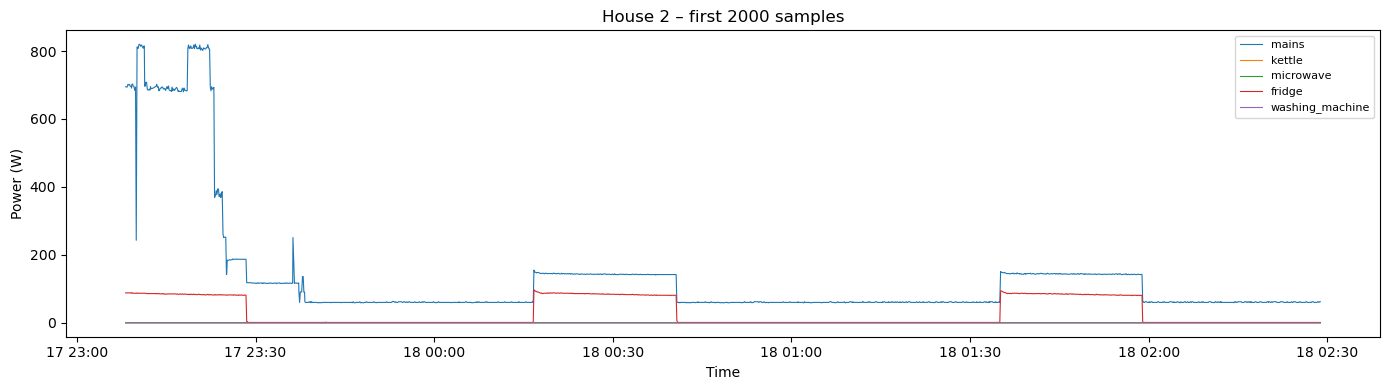

In [10]:
from src.plots import plot_power_trace
ax = plot_power_trace(std.iloc[:2000], title=f'House {house_id} – first 2000 samples')
plt.tight_layout()
plt.show()